# Day 51 — Deep Neural Network Regularization
- Why neural networks overfit
- L1 regularization
- L2 regularization / weight decay
- Dropout
- Monte Carlo Dropout
- Max-Norm regularization
- Early stopping
- Practical regularization strategy
- review: initialization, activation functions, optimizers, learning-rate scheduling, and regularization

## 1. Setup

This notebook uses TensorFlow/Keras and a small synthetic classification dataset so that the regularization effects are easy to see.

If TensorFlow is not installed in your environment:

```bash
pip install tensorflow matplotlib scikit-learn pandas numpy
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

tf.keras.utils.set_random_seed(42)
np.random.seed(42)


TensorFlow: 2.21.0
NumPy: 2.4.6


## 2. What is overfitting?

A model is overfitting when it learns the training data too specifically and performs substantially worse on unseen validation/test data.

Typical pattern:

- Training loss keeps decreasing.
- Validation loss decreases initially.
- Validation loss eventually starts increasing.

The model is becoming better at memorizing the training set rather than learning patterns that generalize.


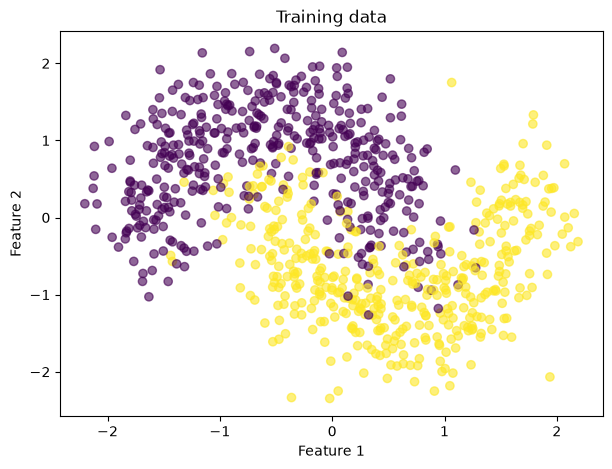

In [2]:
# Create a nonlinear classification dataset
X, y = make_moons(n_samples=1200, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.6)
plt.title("Training data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 3. A deliberately over-parameterized baseline

We start with a relatively large network and no explicit regularization.

This gives us a baseline against which we can compare L1, L2, dropout, and other techniques.


In [3]:
def build_baseline_model():
    return keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

baseline = build_baseline_model()

baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_baseline = baseline.fit(
    X_train, y_train,
    validation_split=0.25,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

baseline.evaluate(X_test, y_test, verbose=0)


[0.14442178606987, 0.9527778029441833]

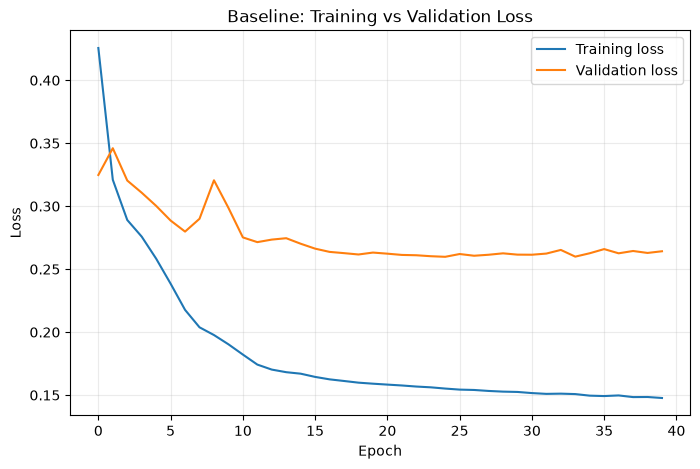

In [4]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

plot_history(history_baseline, "Baseline: Training vs Validation Loss")


## 4. L2 Regularization

### Idea

L2 adds a penalty proportional to the squared weights:

$$
L_{total} = L_{original} + \lambda \sum_i w_i^2
$$

Large weights become costly, encouraging the network to use smaller weights.

In Keras:

```python
layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.001)
)
```

### Mental model

**L2:** "Keep the weights small."

L2 is often a good default regularizer for dense neural networks.


In [5]:
def build_l2_model(l2_strength=0.001):
    return keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_strength)
        ),
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_strength)
        ),
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_strength)
        ),
        layers.Dense(1, activation="sigmoid")
    ])

l2_model = build_l2_model(0.001)

l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_l2 = l2_model.fit(
    X_train, y_train,
    validation_split=0.25,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

l2_model.evaluate(X_test, y_test, verbose=0)


[0.16178694367408752, 0.9527778029441833]

## 5. L1 Regularization

L1 adds a penalty based on the absolute value of the weights:

$$
L_{total} = L_{original} + \lambda \sum_i |w_i|
$$

A useful intuition:

- L1 tends to push some weights toward **exactly zero**.
- This can create sparse models.
- It can behave somewhat like feature/connection selection.

**L1:** "Make many weights unnecessary."

Keras:

```python
layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=keras.regularizers.l1(0.001)
)
```


In [6]:
def build_l1_model(l1_strength=0.001):
    return keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l1(l1_strength)
        ),
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l1(l1_strength)
        ),
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l1(l1_strength)
        ),
        layers.Dense(1, activation="sigmoid")
    ])

l1_model = build_l1_model(0.001)

l1_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_l1 = l1_model.fit(
    X_train, y_train,
    validation_split=0.25,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

l1_model.evaluate(X_test, y_test, verbose=0)


[0.2070166915655136, 0.949999988079071]

## 6. L1 vs L2

| Method | Penalty | Typical effect |
|---|---|---|
| L1 | $\lambda\sum|w|$ | Encourages sparsity |
| L2 | $\lambda\sum w^2$ | Encourages smaller weights |
| L1 + L2 | Combination | Sparse + smaller weights |

A useful mental shortcut:

> **L1 → zero out some weights**  
> **L2 → shrink weights**


## 7. Dropout

Dropout randomly sets a fraction of neuron outputs to zero during training.

For example:

```python
layers.Dropout(0.20)
```

means roughly 20% of the activations are dropped on each training pass.

Important:

- **Training:** dropout ON
- **Normal inference:** dropout OFF
- Keras handles this automatically.

Mental model:

> **Dropout prevents neurons from becoming overly dependent on specific other neurons.**


In [7]:
def build_dropout_model(dropout_rate=0.2):
    return keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")
    ])

dropout_model = build_dropout_model(0.20)

dropout_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_dropout = dropout_model.fit(
    X_train, y_train,
    validation_split=0.25,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

dropout_model.evaluate(X_test, y_test, verbose=0)


[0.13846895098686218, 0.9527778029441833]

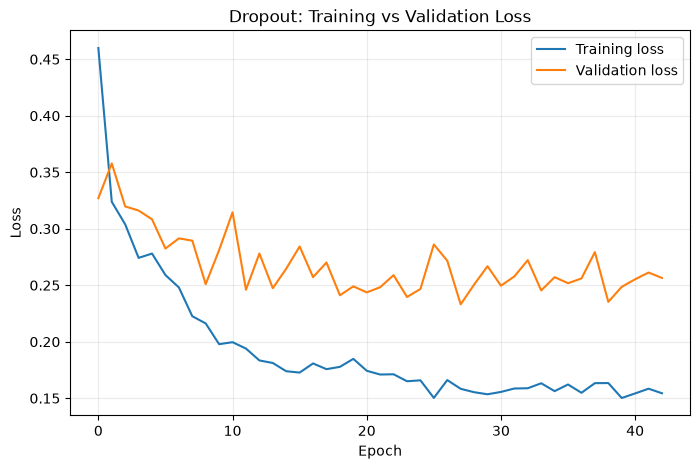

In [8]:
plot_history(history_dropout, "Dropout: Training vs Validation Loss")


## 8. Dropout intuition

Imagine a layer:

```text
Neuron A ──┐
Neuron B ──┼──> Next layer
Neuron C ──┤
Neuron D ──┘
```

With dropout, a training step might temporarily produce:

```text
Neuron A ──┐
Neuron B ──X
Neuron C ──┼──> Next layer
Neuron D ──X
```

On the next step, a different random subset may be dropped.

The network therefore learns representations that are less dependent on a particular collection of neurons.


## 9. Monte Carlo Dropout

Normally, dropout is disabled at inference.

Monte Carlo (MC) Dropout intentionally keeps dropout active and performs multiple stochastic predictions.

Example:

```text
Prediction 1 → 0.82
Prediction 2 → 0.76
Prediction 3 → 0.87
Prediction 4 → 0.79
Prediction 5 → 0.84
```

The mean gives an aggregated prediction, while the spread gives information about model uncertainty.

The key idea is:

> **Run the same input through the model multiple times with dropout enabled.**


In [9]:
# MC Dropout helper
def mc_dropout_predict(model, X, n_samples=100):
    predictions = []

    for _ in range(n_samples):
        # training=True keeps dropout active
        pred = model(X, training=True).numpy().ravel()
        predictions.append(pred)

    predictions = np.array(predictions)

    return {
        "mean": predictions.mean(axis=0),
        "std": predictions.std(axis=0),
        "all_predictions": predictions
    }

mc_result = mc_dropout_predict(dropout_model, X_test[:10], n_samples=100)

mc_summary = pd.DataFrame({
    "mean_prediction": mc_result["mean"],
    "std_uncertainty": mc_result["std"],
    "actual_label": y_test[:10]
})

mc_summary


,mean_prediction,std_uncertainty,actual_label
0,0.000986,0.001149,0
1,0.022311,0.018639,0
2,0.999760,0.000278,1
3,0.000876,0.000965,0
4,0.814782,0.077673,1
5,0.034858,0.019162,1
6,0.985871,0.015093,1
7,0.996453,0.003547,1
8,0.014418,0.009770,0
9,0.001985,0.001587,0


### Why `training=True`?

Normally:

```python
model(X, training=False)
```

means inference behavior, so dropout is disabled.

For MC Dropout:

```python
model(X, training=True)
```

keeps dropout active even though we are making predictions.

This is intentionally different from normal inference.


## 10. Max-Norm Regularization

Max-Norm does not primarily add a penalty to the loss.

Instead, it constrains the magnitude of the incoming weight vector.

Conceptually:

$$
||w|| \leq r
$$

Keras:

```python
layers.Dense(
    128,
    activation="relu",
    kernel_constraint=keras.constraints.MaxNorm(3)
)
```

Mental model:

> **L2:** large weights are expensive.  
> **MaxNorm:** weights must stay inside a specified bound.


In [10]:
def build_maxnorm_model(max_value=3.0):
    return keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(
            256,
            activation="relu",
            kernel_constraint=keras.constraints.MaxNorm(max_value)
        ),
        layers.Dropout(0.10),
        layers.Dense(
            256,
            activation="relu",
            kernel_constraint=keras.constraints.MaxNorm(max_value)
        ),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

maxnorm_model = build_maxnorm_model(3.0)

maxnorm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_maxnorm = maxnorm_model.fit(
    X_train, y_train,
    validation_split=0.25,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

maxnorm_model.evaluate(X_test, y_test, verbose=0)


[0.13568638265132904, 0.9583333134651184]

## 11. Early Stopping

Early stopping monitors validation performance and stops training when it stops improving.

```python
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
```

### What does `patience=5` mean?

Allow five consecutive epochs without improvement before stopping.

### Why `restore_best_weights=True`?

The final epoch is not necessarily the best epoch.

This option restores the model weights from the epoch with the best monitored validation value.


In [11]:
# Example: explicit early-stopping configuration
early_stopping_example = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True
)

print(early_stopping_example)


## 12. Comparing the regularization approaches

Use the following conceptual summary:

| Technique | Main idea | Typical reason to use |
|---|---|---|
| L1 | Penalize absolute weights | Encourage sparsity |
| L2 | Penalize squared weights | Shrink weights / improve generalization |
| Dropout | Randomly drop activations during training | Reduce co-adaptation |
| MC Dropout | Dropout during prediction | Approximate uncertainty |
| Max-Norm | Bound weight magnitude | Prevent weights becoming too large |
| Early stopping | Stop when validation performance stops improving | Avoid training past the generalization point |

There is no universally best regularization technique. The correct choice depends on the model, dataset, amount of data, and validation behavior.


In [12]:
# Collect a simple test-set comparison
models_and_histories = {
    "Baseline": (baseline, history_baseline),
    "L1": (l1_model, history_l1),
    "L2": (l2_model, history_l2),
    "Dropout": (dropout_model, history_dropout),
    "MaxNorm": (maxnorm_model, history_maxnorm),
}

comparison = []

for name, (model, history) in models_and_histories.items():
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    comparison.append({
        "Model": name,
        "Test Loss": loss,
        "Test Accuracy": accuracy,
        "Epochs Trained": len(history.history["loss"])
    })

pd.DataFrame(comparison).sort_values("Test Accuracy", ascending=False)


,Model,Test Loss,Test Accuracy,Epochs Trained
4,MaxNorm,0.135686,0.958333,42
0,Baseline,0.144422,0.952778,40
2,L2,0.161787,0.952778,150
3,Dropout,0.138469,0.952778,43
1,L1,0.207017,0.950000,150


## 13. Avoiding Overfitting — Practical Decision Tree

When validation performance is poor:

```text
                 Validation performance poor
                           |
                    Is training poor?
                    /              \
                  YES               NO
                   |                 |
             Underfitting        Overfitting
                   |                 |
          Increase capacity       Try regularization
          / improve features      and/or more data
                                     |
                ┌────────────────────┼───────────────────┐
                |                    |                   |
           Early stopping          L2                 Dropout
                |                    |                   |
         stop at best epoch    shrink weights       reduce co-adaptation
```

Other options:

- More training data
- Data augmentation
- Smaller network
- Feature engineering
- Better preprocessing
- Learning-rate tuning
- Batch normalization where appropriate


## A. Gradient problems

### Vanishing gradients

Gradients become extremely small as they propagate backward.

Result:

```text
Early layers
     ↓
tiny gradients
     ↓
very slow learning
```

### Exploding gradients

Gradients become extremely large.

Result:

```text
unstable updates
      ↓
NaN / divergence
```

---

## B. Weight initialization

### Glorot/Xavier initialization

Designed to maintain a reasonable signal variance through layers, particularly useful with activations such as tanh/logistic.

### He initialization

Especially appropriate for ReLU-family activations.

```python
layers.Dense(
    128,
    activation="relu",
    kernel_initializer="he_normal"
)
```

Mental shortcut:

> **ReLU → think He initialization.**


## C. Activation functions

Important activation functions from Chapter 11:

- ReLU
- Leaky ReLU
- PReLU
- ELU
- SELU

### Why move beyond ordinary ReLU?

ReLU can suffer from the "dying ReLU" problem: a neuron can become stuck producing zero for many/all inputs.

Leaky ReLU gives the negative side a small slope.

ELU provides a smooth negative region.

SELU can help maintain self-normalizing behavior under its required architectural/training conditions.


## D. Faster optimizers

### Momentum

Adds a velocity-like component to gradient descent.

### Nesterov Accelerated Gradient

Looks ahead before calculating the gradient.

### AdaGrad

Adapts the learning rate separately for parameters.

### RMSProp

Uses an exponentially decaying average of squared gradients.

### Adam

Combines momentum-like first-moment tracking with second-moment tracking.

### Nadam

Adam + Nesterov-style momentum.

Mental progression:

```text
Gradient Descent
      ↓
Momentum
      ↓
Nesterov
      ↓
Adaptive methods
      ↓
AdaGrad / RMSProp
      ↓
Adam
      ↓
Nadam
```


## E. Learning-rate scheduling

The learning rate does not necessarily need to stay constant.

Important schedules:

1. Power scheduling
2. Exponential scheduling
3. Piecewise constant scheduling
4. Performance scheduling
5. 1cycle scheduling

### Key idea

```text
Large learning rate
      ↓
faster movement early
      ↓
smaller learning rate
      ↓
finer convergence
```

The learning rate is often one of the most important hyperparameters to tune.


# 15. Final Mental Model

When training a deep neural network, think through the pipeline:

```text
                    Neural Network Training
                             |
        ┌────────────────────┼────────────────────┐
        |                    |                    |
 Initialization       Activation Functions    Optimization
        |                    |                    |
   Glorot / He         ReLU / ELU / SELU      Adam / RMSProp
        |                    |                    |
        └────────────────────┼────────────────────┘
                             |
                    Learning-rate schedule
                             |
                       Generalization
                             |
                  ┌──────────┼──────────┐
                  |          |          |
                 L1         L2       Dropout
                  |          |          |
               sparse      small     robust
               weights     weights   features
                  |          |          |
                  └──────────┼──────────┘
                             |
                       Early Stopping
                             |
                       Better validation
```

**L1:** "Make some weights zero."

**L2:** "Keep weights small."

**Dropout:** "Don't rely too heavily on particular neurons."

**Early stopping:** "Stop when validation performance stops improving."

**MC Dropout:** "Use dropout randomness at inference to estimate uncertainty."

**Max-Norm:** "Keep weight magnitude under a limit."
